In [1]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb

In [3]:
df=pd.read_csv('autos.csv')
df.head()

,index,dateCrawled,name,seller,offerType,price,abtest,vehicleType,yearOfRegistration,gearbox,...,model,kilometer,monthOfRegistration,fuelType,brand,notRepairedDamage,dateCreated,nrOfPictures,postalCode,lastSeen
0,0,2016-03-24 11:52:17,Golf_3_1.6,privat,Angebot,480,test,NaN,1993,manuell,...,golf,150000,0,benzin,volkswagen,NaN,2016-03-24 00:00:00,0,70435,2016-04-07 03:16:57
1,1,2016-03-24 10:58:45,A5_Sportback_2.7_Tdi,privat,Angebot,18300,test,coupe,2011,manuell,...,NaN,125000,5,diesel,audi,ja,2016-03-24 00:00:00,0,66954,2016-04-07 01:46:50
2,2,2016-03-14 12:52:21,"Jeep_Grand_Cherokee_""Overland""",privat,Angebot,9800,test,suv,2004,automatik,...,grand,125000,8,diesel,jeep,NaN,2016-03-14 00:00:00,0,90480,2016-04-05 12:47:46
3,3,2016-03-17 16:54:04,GOLF_4_1_4__3TÜRER,privat,Angebot,1500,test,kleinwagen,2001,manuell,...,golf,150000,6,benzin,volkswagen,nein,2016-03-17 00:00:00,0,91074,2016-03-17 17:40:17
4,4,2016-03-31 17:25:20,Skoda_Fabia_1.4_TDI_PD_Classic,privat,Angebot,3600,test,kleinwagen,2008,manuell,...,fabia,90000,7,diesel,skoda,nein,2016-03-31 00:00:00,0,60437,2016-04-06 10:17:21


In [4]:
df.shape

(371528, 21)

In [5]:
df.dtypes

index                   int64
dateCrawled            object
name                   object
seller                 object
offerType              object
price                   int64
abtest                 object
vehicleType            object
yearOfRegistration      int64
gearbox                object
powerPS                 int64
model                  object
kilometer               int64
monthOfRegistration     int64
fuelType               object
brand                  object
notRepairedDamage      object
dateCreated            object
nrOfPictures            int64
postalCode              int64
lastSeen               object
dtype: object

In [6]:
df.isna().sum().sort_values(ascending=False)

notRepairedDamage      72060
vehicleType            37869
fuelType               33386
model                  20484
gearbox                20209
index                      0
kilometer                  0
postalCode                 0
nrOfPictures               0
dateCreated                0
brand                      0
monthOfRegistration        0
powerPS                    0
dateCrawled                0
yearOfRegistration         0
abtest                     0
price                      0
offerType                  0
seller                     0
name                       0
lastSeen                   0
dtype: int64

In [7]:
most_npd=df['notRepairedDamage'].value_counts(ascending=False).index[0]
df['notRepairedDamage'].fillna(most_npd,inplace=True)

In [8]:
most_vt=df['vehicleType'].value_counts(ascending=False).index[0]
df['vehicleType'].fillna(most_vt,inplace=True)

In [9]:
most_ft=df['fuelType'].value_counts(ascending=False).index[0]
df['fuelType'].fillna(most_ft,inplace=True)

In [10]:
most_gb=df['gearbox'].value_counts(ascending=False).index[0]
df['gearbox'].fillna(most_gb,inplace=True)

In [11]:
df['model'].fillna('unkown',inplace=True)

In [12]:
df['dateCreated']=pd.to_datetime(df['dateCreated'])
df['dateCreated']=df['dateCreated'].dt.strftime('%Y-%m')

In [13]:
df['lastSeen']=pd.to_datetime(df['lastSeen'])
df['lastSeen']=df['lastSeen'].dt.strftime('%Y-%m')

In [14]:
df.describe()

,index,price,yearOfRegistration,powerPS,kilometer,monthOfRegistration,nrOfPictures,postalCode
count,371528.000000,3.715280e+05,371528.000000,371528.000000,371528.000000,371528.000000,371528.0,371528.00000
mean,185763.500000,1.729514e+04,2004.577997,115.549477,125618.688228,5.734445,0.0,50820.66764
std,107251.039743,3.587954e+06,92.866598,192.139578,40112.337051,3.712412,0.0,25799.08247
min,0.000000,0.000000e+00,1000.000000,0.000000,5000.000000,0.000000,0.0,1067.00000
25%,92881.750000,1.150000e+03,1999.000000,70.000000,125000.000000,3.000000,0.0,30459.00000
50%,185763.500000,2.950000e+03,2003.000000,105.000000,150000.000000,6.000000,0.0,49610.00000
75%,278645.250000,7.200000e+03,2008.000000,150.000000,150000.000000,9.000000,0.0,71546.00000
max,371527.000000,2.147484e+09,9999.000000,20000.000000,150000.000000,12.000000,0.0,99998.00000


In [15]:
def outlier_remover(df):
    Q1 = df.quantile(.1, numeric_only=True) 
    Q3 = df.quantile(.9, numeric_only=True)
    IQR = Q3 - Q1 
    return df[~((df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR))).any(axis=1)]
clean_df = outlier_remover(df)

/var/folders/dr/05g6dmcd47v9mvnt25smv94h0000gn/T/ipykernel_40648/2430721828.py:5: FutureWarning: Automatic reindexing on DataFrame vs Series comparisons is deprecated and will raise ValueError in a future version. Do `left, right = left.align(right, axis=1, copy=False)` before e.g. `left == right`
  return df[~((df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR))).any(axis=1)]


<function matplotlib.pyplot.show(close=None, block=None)>

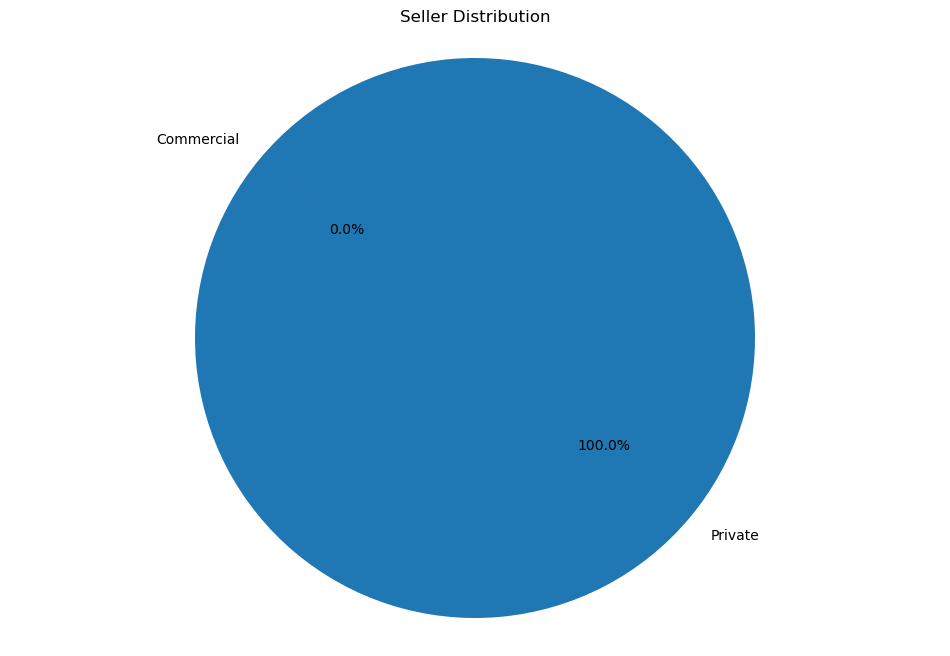

In [16]:
seller_count=df['seller'].value_counts()
plt.figure(figsize=(12,8))
plt.pie(seller_count,labels=['Private','Commercial'],autopct='%1.1f%%', startangle=140)
plt.axis('equal')
plt.title('Seller Distribution')
plt.show

In [17]:
seller_count

privat        371525
gewerblich         3
Name: seller, dtype: int64

<function matplotlib.pyplot.show(close=None, block=None)>

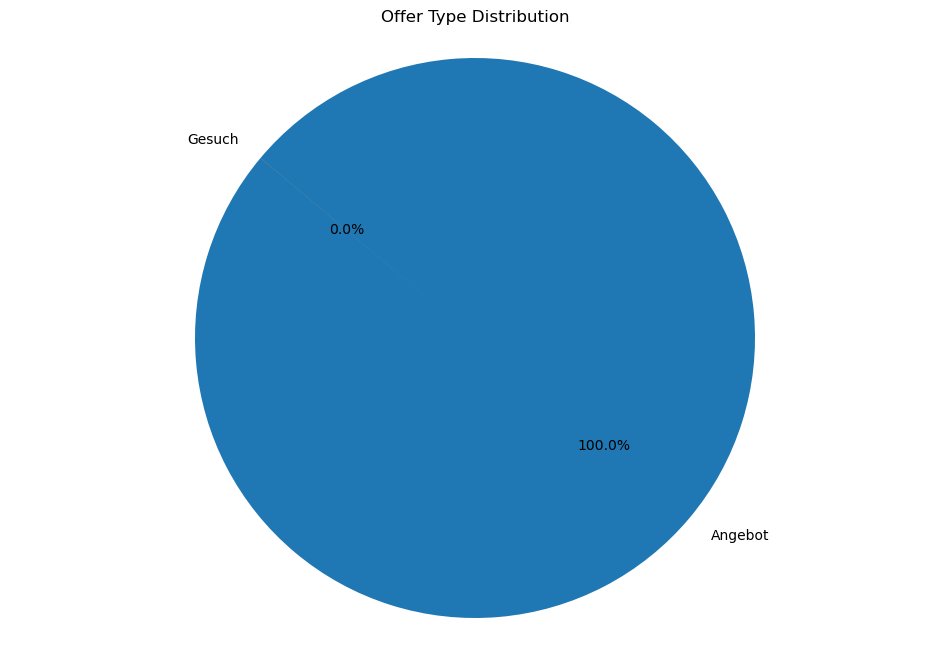

In [18]:
offer_count=df['offerType'].value_counts()
plt.figure(figsize=(12,8))
plt.pie(offer_count,labels=offer_count.index,autopct='%1.1f%%', startangle=140)
plt.axis('equal')
plt.title('Offer Type Distribution')
plt.show

In [19]:
offer_count

Angebot    371516
Gesuch         12
Name: offerType, dtype: int64

<function matplotlib.pyplot.show(close=None, block=None)>

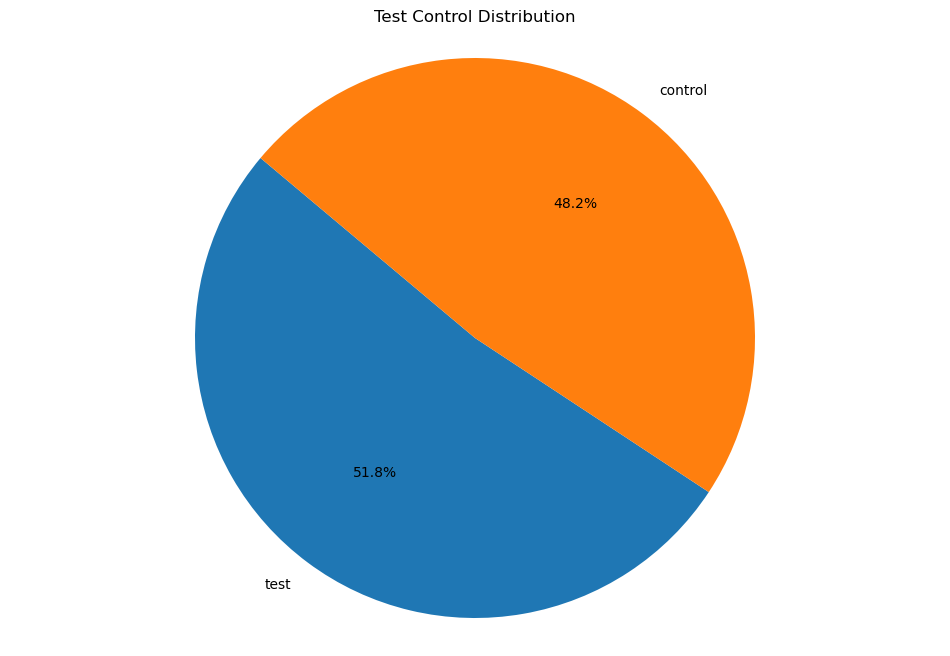

In [20]:
ab_count=df['abtest'].value_counts()
plt.figure(figsize=(12,8))
plt.pie(ab_count,labels=ab_count.index,autopct='%1.1f%%', startangle=140)
plt.axis('equal')
plt.title('Test Control Distribution')
plt.show

In [21]:
df['yearOfRegistration'].value_counts()

2000    24551
1999    22767
2005    22316
2006    20230
2001    20218
        ...  
2066        1
9450        1
3200        1
1925        1
3500        1
Name: yearOfRegistration, Length: 155, dtype: int64

In [22]:
df[df['yearOfRegistration']>2023]

,index,dateCrawled,name,seller,offerType,price,abtest,vehicleType,yearOfRegistration,gearbox,...,model,kilometer,monthOfRegistration,fuelType,brand,notRepairedDamage,dateCreated,nrOfPictures,postalCode,lastSeen
13576,13576,2016-03-29 18:39:40,Verkaufe_DESIGN_Streifen_/_Aufkleber_VW__Opel_...,privat,Angebot,49,control,limousine,5000,manuell,...,golf,5000,12,benzin,volkswagen,nein,2016-03,0,74523,2016-04
15894,15894,2016-03-14 00:52:02,Alles_anbieten,privat,Angebot,0,control,limousine,9999,manuell,...,unkown,10000,0,benzin,sonstige_autos,nein,2016-03,0,32689,2016-03
16657,16657,2016-04-02 11:55:48,quad_neu_t?v_tauschen_gegen_Auto,privat,Angebot,1700,test,limousine,3200,manuell,...,unkown,5000,0,benzin,sonstige_autos,nein,2016-04,0,33649,2016-04
18121,18121,2016-03-23 16:43:29,Opel_GT_Karosserie_mit_Brief!,privat,Angebot,700,test,limousine,9999,manuell,...,andere,10000,0,benzin,opel,nein,2016-03,0,21769,2016-04
18196,18196,2016-03-06 16:06:20,Reo_Vorkriegs_Oldtimer_Rennwagen_1928,privat,Angebot,6500,control,limousine,8888,manuell,...,unkown,10000,0,benzin,sonstige_autos,nein,2016-03,0,55262,2016-03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
351235,351235,2016-03-20 17:53:51,Vw_Golf_1_16v_Turbo,privat,Angebot,12000,test,limousine,4000,manuell,...,golf,5000,0,benzin,volkswagen,nein,2016-03,0,57392,2016-04
352029,352029,2016-03-09 07:01:27,Mini_MK2_Top_ohne_Rost_sucht_neuen_Liebhaber,privat,Angebot,0,control,limousine,7500,manuell,...,andere,10000,0,benzin,mini,nein,2016-03,0,9669,2016-03
355280,355280,2016-03-24 19:49:36,Golf_4_Karosse_schrott_Kupfer,privat,Angebot,50,control,limousine,3000,manuell,...,golf,100000,6,benzin,volkswagen,ja,2016-03,0,23992,2016-04
357075,357075,2016-04-02 17:44:03,Tausche_hier_mein_Quad,privat,Angebot,0,control,limousine,3500,manuell,...,unkown,5000,3,benzin,sonstige_autos,nein,2016-04,0,96465,2016-04


In [23]:
df.loc[df['yearOfRegistration'] > 2023, 'yearOfRegistration'] = df['yearOfRegistration'].mode()[0]
df.loc[df['yearOfRegistration']<1950,'yearOfRegistration']=df['yearOfRegistration'].mode()[0]

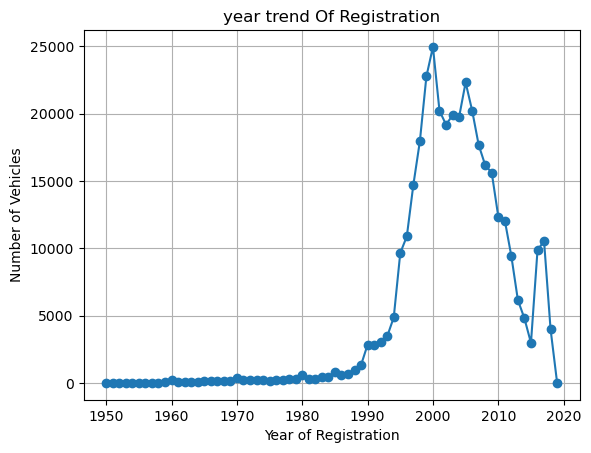

In [24]:
year_counts = df.groupby('yearOfRegistration').size()
plt.plot(year_counts.index ,year_counts , marker='o')

plt.title('year trend Of Registration') 
plt.xlabel('Year of Registration')
plt.ylabel('Number of Vehicles')
plt.grid(True)

plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

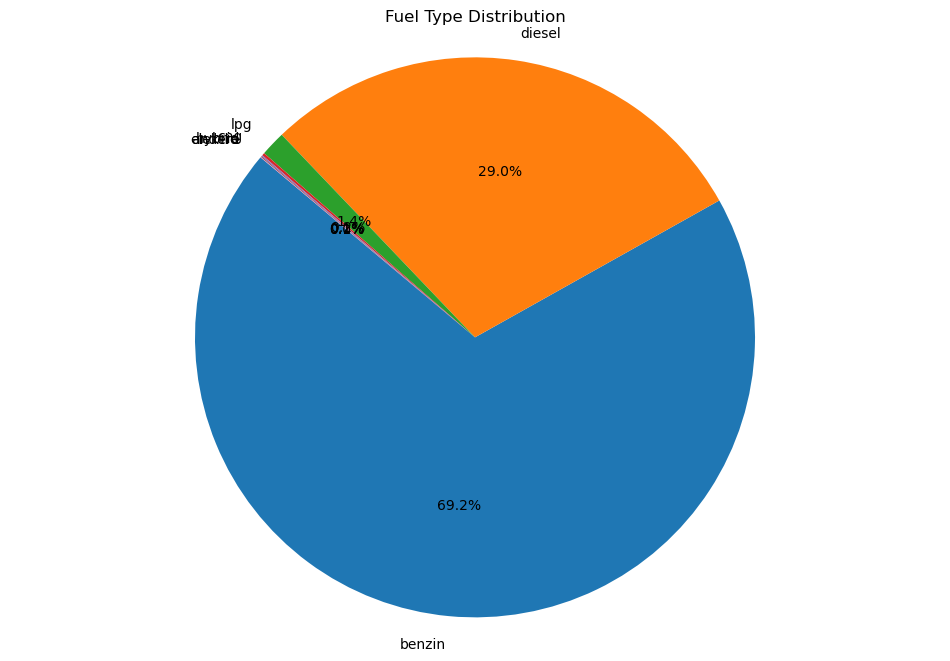

In [25]:
fuel_count=df['fuelType'].value_counts()
plt.figure(figsize=(12,8))
plt.pie(fuel_count,labels=fuel_count.index,autopct='%1.1f%%', startangle=140)
plt.axis('equal')
plt.title('Fuel Type Distribution')
plt.show

In [26]:
df['brand'].unique()

array(['volkswagen', 'audi', 'jeep', 'skoda', 'bmw', 'peugeot', 'ford',
       'mazda', 'nissan', 'renault', 'mercedes_benz', 'opel', 'seat',
       'citroen', 'honda', 'fiat', 'mini', 'smart', 'hyundai',
       'sonstige_autos', 'alfa_romeo', 'subaru', 'volvo', 'mitsubishi',
       'kia', 'suzuki', 'lancia', 'porsche', 'toyota', 'chevrolet',
       'dacia', 'daihatsu', 'trabant', 'saab', 'chrysler', 'jaguar',
       'daewoo', 'rover', 'land_rover', 'lada'], dtype=object)

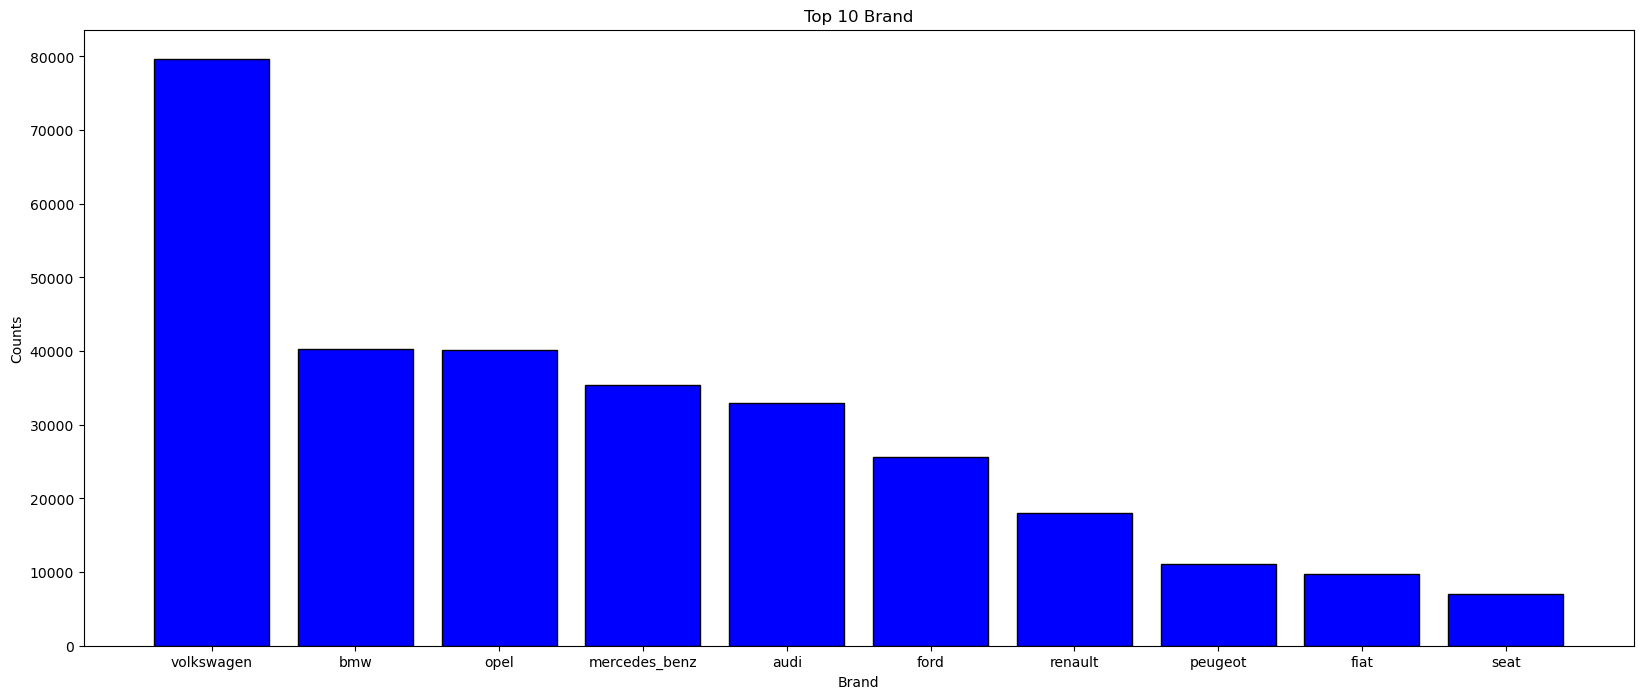

In [27]:
brand_count=df['brand'].value_counts()
top10brand=brand_count.nlargest(10)
plt.figure(figsize=(20,8))
plt.bar(top10brand.index,top10brand.values,color='blue', edgecolor='black')
plt.title('Top 10 Brand')  # Add a title
plt.xlabel('Brand')  # Add x-axis label
plt.ylabel('Counts')  # Add y-axis label
plt.show()

In [28]:
#i want to know the average lasting year for each brand
# so the way of doing it will be sum(2023-yearofregis)/count(brand)
df['car_age']=2023-df['yearOfRegistration']
avg_age_brand=df.groupby('brand')['car_age'].mean()
avg_age_brand

brand
alfa_romeo        20.396162
audi              18.747452
bmw               19.668123
chevrolet         20.369648
chrysler          21.092975
citroen           18.366461
dacia             12.545556
daewoo            20.003690
daihatsu          20.116625
fiat              19.401819
ford              19.461698
honda             20.659379
hyundai           15.636588
jaguar            23.083736
jeep              21.185874
kia               15.715460
lada              21.195556
lancia            21.991736
land_rover        19.028571
mazda             19.667779
mercedes_benz     20.553145
mini              15.365351
mitsubishi        20.339432
nissan            19.164781
opel              20.176724
peugeot           18.711798
porsche           21.646501
renault           19.362569
rover             22.285714
saab              23.105660
seat              17.661777
skoda             15.946286
smart             17.154125
sonstige_autos    27.332496
subaru            21.332478
suzuki        

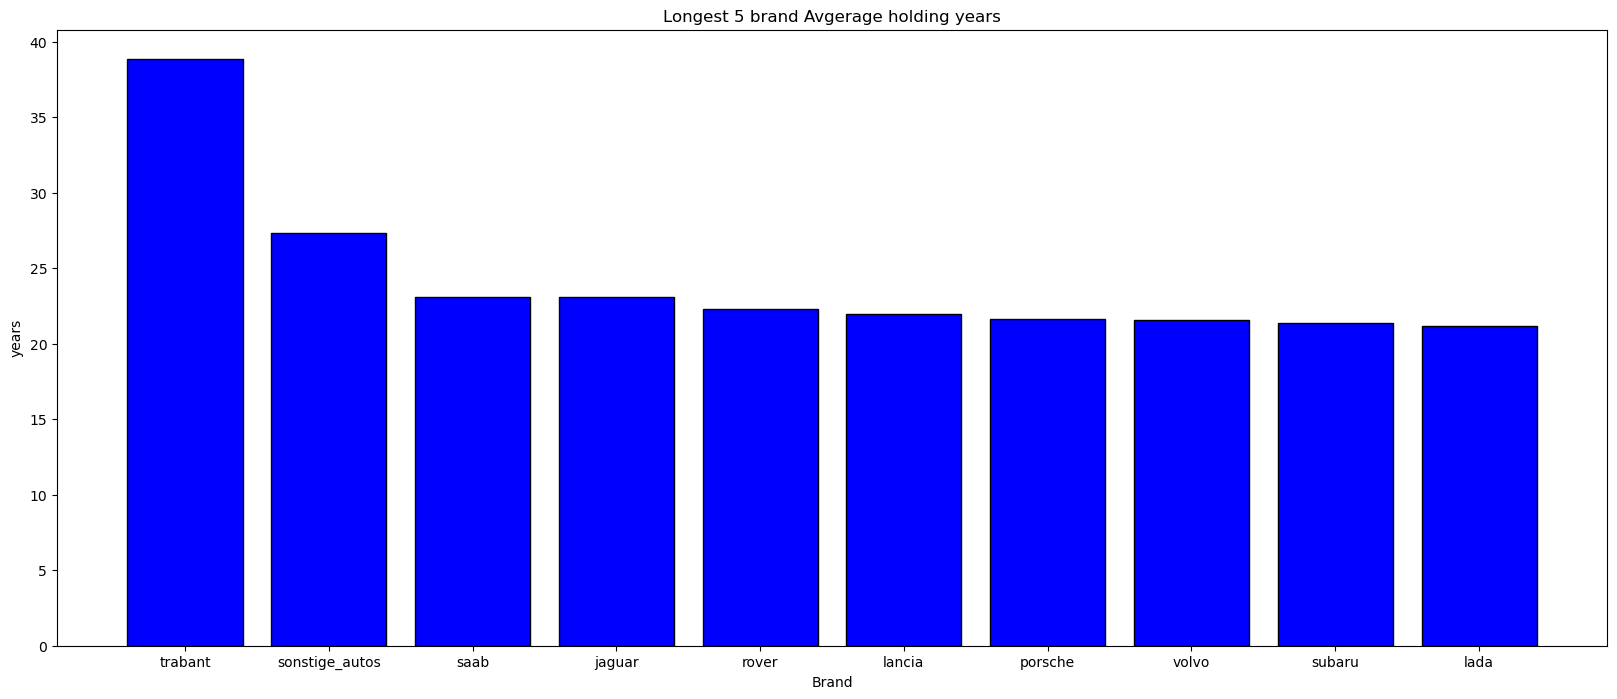

In [29]:
longest5=avg_age_brand.nlargest(10)
plt.figure(figsize=(20,8))
plt.bar(longest5.index,longest5.values,color='blue', edgecolor='black')
plt.title('Longest 5 brand Avgerage holding years')  # Add a title
plt.xlabel('Brand')  # Add x-axis label
plt.ylabel('years')  # Add y-axis label
plt.show()

In [30]:
avg_km_brand=df.groupby('brand')['kilometer'].mean()
avg_km_brand

brand
alfa_romeo        128842.217484
audi              129717.397256
bmw               132763.569549
chevrolet         100116.531165
chrysler          134084.022039
citroen           120512.350444
dacia              86427.777778
daewoo            123376.383764
daihatsu          119044.665012
fiat              116854.588673
ford              123839.987487
honda             125943.229901
hyundai           104695.556775
jaguar            121940.418680
jeep              120960.346964
kia               109643.835616
lada               75266.666667
lancia            124524.793388
land_rover        119240.259740
mazda             125988.586479
mercedes_benz     130664.703050
mini               94668.532705
mitsubishi        126924.207775
nissan            119789.557276
opel              128906.592585
peugeot           124970.073456
porsche            98316.027088
renault           128049.140186
rover             134602.040816
saab              141216.981132
seat              121473.939049
sk

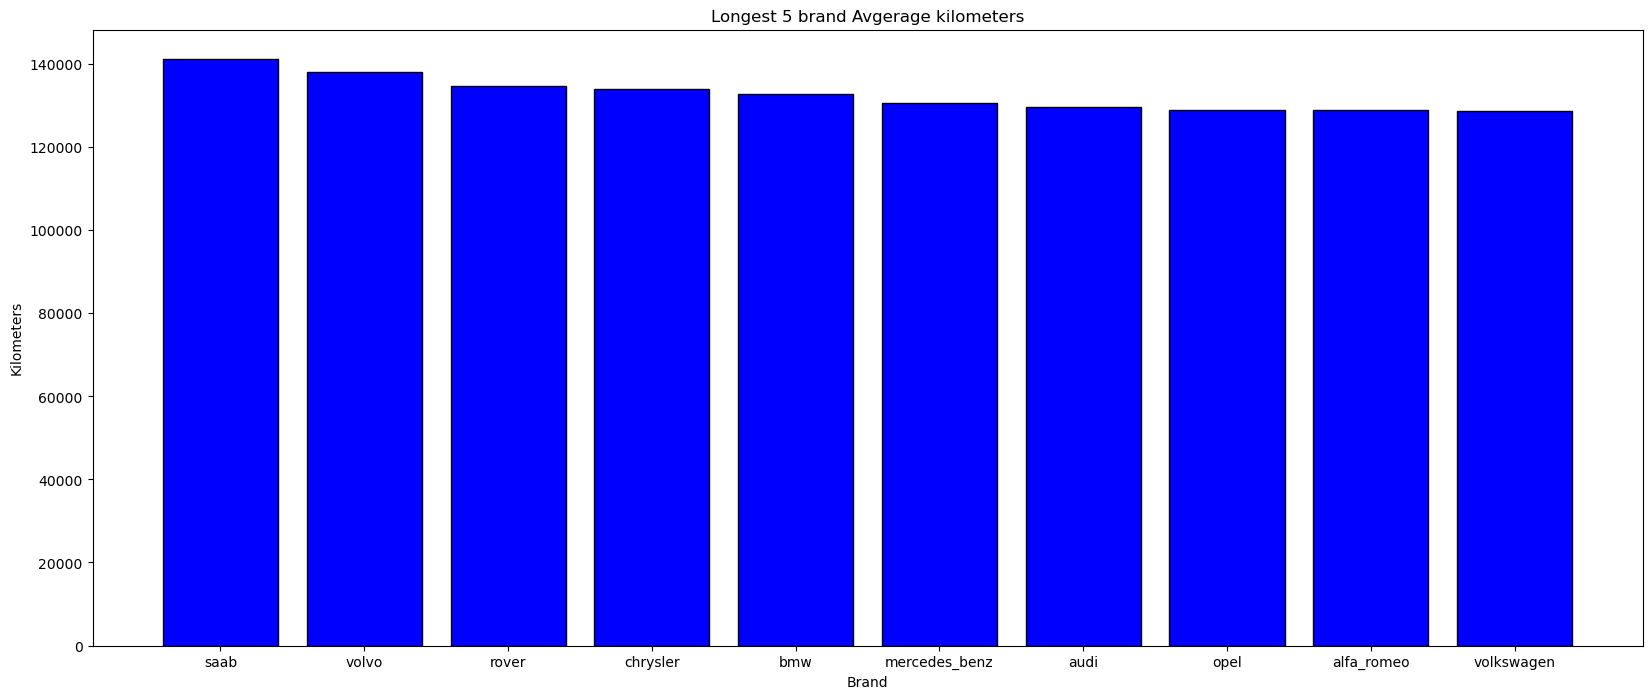

In [31]:
long5=avg_km_brand.nlargest(10)
plt.figure(figsize=(20,8))
plt.bar(long5.index,long5.values,color='blue', edgecolor='black')
plt.title('Longest 5 brand Avgerage kilometers')  # Add a title
plt.xlabel('Brand')  # Add x-axis label
plt.ylabel('Kilometers')  # Add y-axis label
plt.show()

In [32]:
df['notRepairedDamage'].unique()

array(['nein', 'ja'], dtype=object)

In [33]:
df.groupby('abtest')['notRepairedDamage'].count()

abtest
control    178943
test       192585
Name: notRepairedDamage, dtype: int64

In [34]:
df_ab_rep=df[['abtest','notRepairedDamage']]
test_rep_pivot_table=df_ab_rep.groupby(['abtest','notRepairedDamage']).size().unstack(fill_value=0)
test_rep_pivot_table.columns=['yes','no']
test_rep_pivot_table

,yes,no
abtest,,
control,17509,161434
test,18777,173808


<Axes: xlabel='abtest', ylabel='count'>

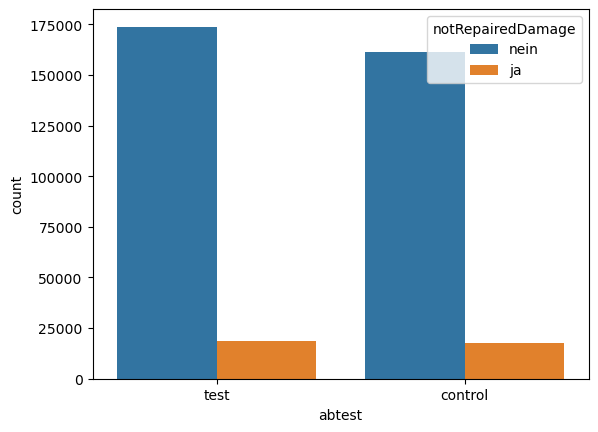

In [35]:
sb.countplot(data=df,x='abtest',hue='notRepairedDamage')

In [36]:
avg_price_brand=df.groupby('brand')['price'].mean()
avg_price_brand

brand
alfa_romeo         35737.169723
audi               15868.514221
bmw                14844.144883
chevrolet           7447.764228
chrysler            3916.025482
citroen             8880.624855
dacia               5839.654444
daewoo              1017.811808
daihatsu            1693.656328
fiat                5326.312836
ford                8462.054706
honda               3804.630113
hyundai             5415.057049
jaguar             14228.083736
jeep               12009.677819
kia                 5656.574168
lada                3037.444444
lancia              3165.754132
land_rover         16707.559740
mazda               5680.361194
mercedes_benz      17244.060438
mini                9846.432233
mitsubishi          3273.896766
nissan              4527.510820
opel                3223.522449
peugeot             3166.981591
porsche            51089.857336
renault             2334.258946
rover               1508.022449
saab                3820.041509
seat                4356.666050
sk

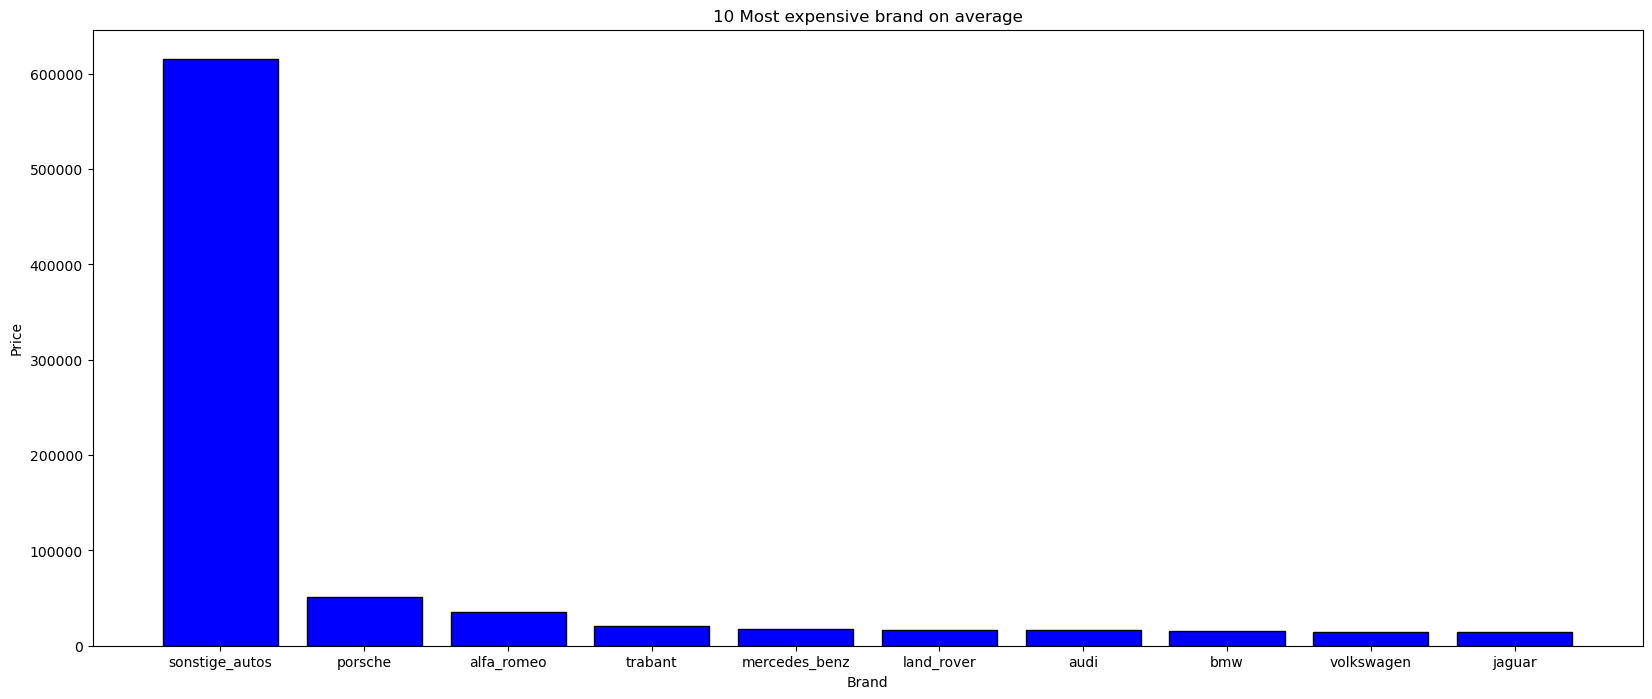

In [37]:
top10exp=avg_price_brand.nlargest(10)
plt.figure(figsize=(20,8))
plt.bar(top10exp.index,top10exp.values,color='blue', edgecolor='black')
plt.title('10 Most expensive brand on average')  # Add a title
plt.xlabel('Brand')  # Add x-axis label
plt.ylabel('Price')  # Add y-axis label
plt.show()

In [39]:
df.isna().sum()

index                  0
dateCrawled            0
name                   0
seller                 0
offerType              0
price                  0
abtest                 0
vehicleType            0
yearOfRegistration     0
gearbox                0
powerPS                0
model                  0
kilometer              0
monthOfRegistration    0
fuelType               0
brand                  0
notRepairedDamage      0
dateCreated            0
nrOfPictures           0
postalCode             0
lastSeen               0
car_age                0
dtype: int64

In [40]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
encoder=clean_df.copy()
cat_col=['seller','offerType','abtest','vehicleType','model',
         'fuelType','brand','notRepairedDamage','gearbox']
encoder[cat_col]=encoder[cat_col].apply(le.fit_transform)

/var/folders/dr/05g6dmcd47v9mvnt25smv94h0000gn/T/ipykernel_40648/841681834.py:1: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  corr=encoder.corr()


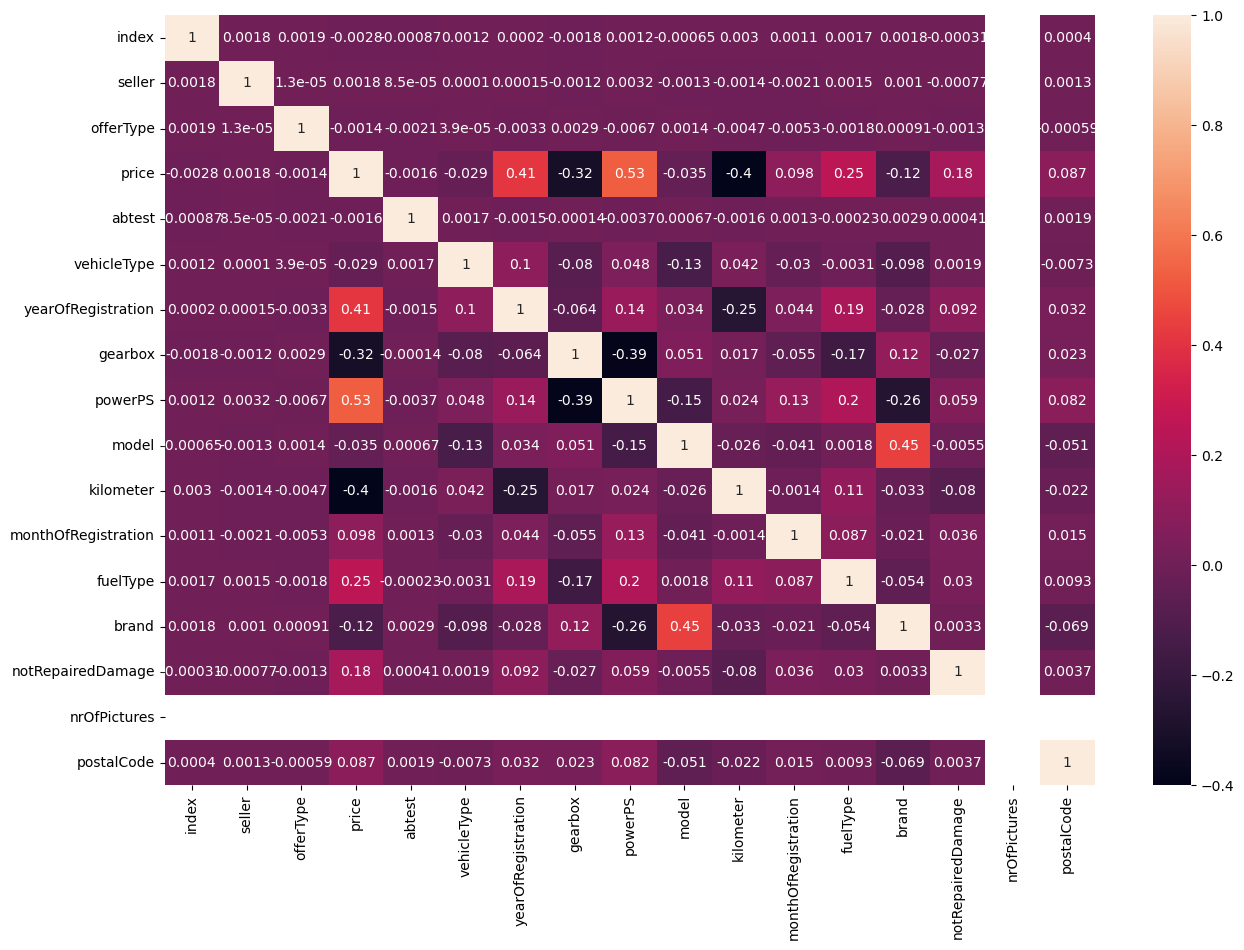

In [41]:
corr=encoder.corr()
plt.figure(figsize=(15, 10))
sb.heatmap(corr,annot=True)
plt.show()

In [42]:
print(abs(encoder.corr()['price']).sort_values(ascending=False))

price                  1.000000
powerPS                0.526609
yearOfRegistration     0.412611
kilometer              0.400107
gearbox                0.315482
fuelType               0.250859
notRepairedDamage      0.175822
brand                  0.122446
monthOfRegistration    0.098431
postalCode             0.086772
model                  0.034840
vehicleType            0.029437
index                  0.002837
seller                 0.001801
abtest                 0.001557
offerType              0.001403
nrOfPictures                NaN
Name: price, dtype: float64


/var/folders/dr/05g6dmcd47v9mvnt25smv94h0000gn/T/ipykernel_40648/16113803.py:1: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  print(abs(encoder.corr()['price']).sort_values(ascending=False))


In [44]:
X=encoder.drop(columns=['price','lastSeen','dateCreated','dateCrawled','index','name',
                        'postalCode','nrOfPictures','monthOfRegistration'])
y=encoder['price']

In [45]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaled_data = scaler.fit_transform(X)

In [46]:
pca = PCA(n_components=5)
pca_result = pca.fit_transform(scaled_data)

In [47]:
print("Singular Values (Eigenvalues):", pca.singular_values_)


cumulative_explained_variance = np.cumsum(pca.explained_variance_ratio_)
print("Cumulative Explained Variance:", cumulative_explained_variance)


summary_df = pd.DataFrame({
    'Principal Component': range(1, len(pca.explained_variance_ratio_) + 1),
    'Explained Variance Ratio': pca.explained_variance_ratio_,
    'Cumulative Explained Variance': cumulative_explained_variance
})
print(summary_df)

Singular Values (Eigenvalues): [823.20503322 710.10886219 660.29244499 604.96113821 604.29759857]
Cumulative Explained Variance: [0.15465313 0.2697312  0.36922943 0.45275081 0.53608907]
   Principal Component  Explained Variance Ratio  \
0                    1                  0.154653   
1                    2                  0.115078   
2                    3                  0.099498   
3                    4                  0.083521   
4                    5                  0.083338   

   Cumulative Explained Variance  
0                       0.154653  
1                       0.269731  
2                       0.369229  
3                       0.452751  
4                       0.536089  


In [48]:
pca_df = pd.DataFrame(pca.components_, columns=X.columns, index=['Dim1', 'Dim2', 'Dim3', 'Dim4', 'Dim5'])

print(pca_df)

        seller  offerType    abtest  vehicleType  yearOfRegistration  \
Dim1  0.003060  -0.008207 -0.004073     0.205607            0.209906   
Dim2 -0.003287   0.003065 -0.001632     0.089208           -0.541048   
Dim3 -0.003697   0.019556  0.004028     0.206905            0.294071   
Dim4  0.014227   0.676836 -0.728862    -0.090727           -0.023078   
Dim5 -0.998084  -0.018091 -0.041298     0.028238            0.011841   

       gearbox   powerPS     model  kilometer  fuelType     brand  \
Dim1 -0.423594  0.525698 -0.383654   0.013258  0.287734 -0.469979   
Dim2  0.193725 -0.127374 -0.449506   0.405948 -0.279449 -0.359199   
Dim3  0.293596 -0.206004 -0.334293  -0.586454 -0.424591 -0.238596   
Dim4 -0.013035  0.022112 -0.004106  -0.025004 -0.004603 -0.017983   
Dim5  0.006993 -0.009528  0.004977   0.019224  0.013569  0.001694   

      notRepairedDamage  
Dim1           0.082120  
Dim2          -0.267521  
Dim3           0.220860  
Dim4           0.006390  
Dim5           0.01173

In [49]:
from sklearn.model_selection import train_test_split, cross_validate
X_train, X_test, y_train, y_test = train_test_split(pca_result, y, test_size=0.2, random_state=42)

In [50]:
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, make_scorer
scores = {"r2_score" : make_scorer(r2_score), 
          "mae" : make_scorer(mean_absolute_error), 
          "mse" : make_scorer(mean_squared_error)}

In [51]:
model = xgb.XGBRegressor(tree_method="hist", n_estimators = 1000)
xgb_res = cross_validate(model, X_train, y_train, cv = 5, verbose = 2, scoring=scores)

[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.


[CV] END .................................................... total time=   2.5s


[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    2.5s remaining:    0.0s


[CV] END .................................................... total time=   2.8s
[CV] END .................................................... total time=   2.9s
[CV] END .................................................... total time=   2.4s
[CV] END .................................................... total time=   2.7s


[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:   13.2s finished


In [52]:
for index, value in xgb_res.items():
    print(f"{index} : {np.mean(value)} +- {np.std(value)}")

fit_time : 2.522961902618408 +- 0.18129518839462438
score_time : 0.12245717048645019 +- 0.008386698373035087
test_r2_score : 0.7649596715299577 +- 0.005598992748286331
test_mae : 1652.6561252756117 +- 6.462453352384975
test_mse : 8140754.010789844 +- 173883.42409701782


In [53]:
model.fit(X_train, y_train)
pred = model.predict(X_test)
print(f"R2 Score : {r2_score(y_test, pred)}")

R2 Score : 0.7741596959192177


In [54]:
mse = mean_squared_error(y_test, pred) 
mse

7817664.947538884

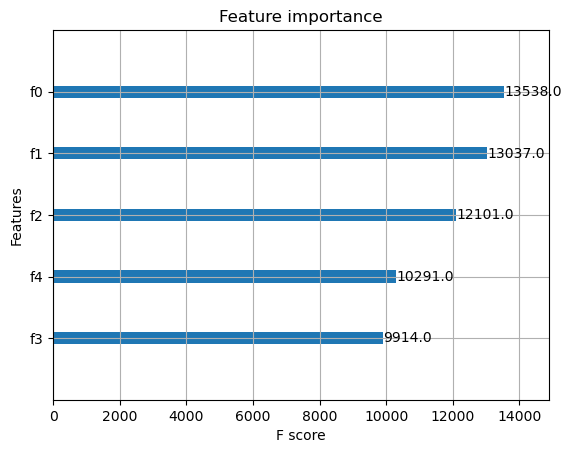

In [55]:
from xgboost import plot_importance
plot_importance(model)
plt.show()

In [56]:
residuals = y_test - pred
mean_residuals = np.mean(residuals)
print('mean_res:', mean_residuals)

mean_res: 10.324001815717638


In [57]:
no_pca_df=encoder.copy()
X=no_pca_df.drop(columns=['price','lastSeen','dateCreated','dateCrawled','index','name',
                        'postalCode','nrOfPictures','monthOfRegistration'])
y=no_pca_df['price']

In [62]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [63]:
scores = {"r2_score" : make_scorer(r2_score), 
          "mae" : make_scorer(mean_absolute_error), 
          "mse" : make_scorer(mean_squared_error)}
model = xgb.XGBRegressor(tree_method="hist", n_estimators = 1000)
xgb_res = cross_validate(model, X_train, y_train, cv = 5, verbose = 2, scoring=scores)

[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.


[CV] END .................................................... total time=   3.1s


[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    3.1s remaining:    0.0s


[CV] END .................................................... total time=   2.8s
[CV] END .................................................... total time=   2.8s
[CV] END .................................................... total time=   2.8s
[CV] END .................................................... total time=   2.8s


[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:   14.3s finished


In [64]:
for index, value in xgb_res.items():
    print(f"{index} : {np.mean(value)} +- {np.std(value)}")

fit_time : 2.7355348110198974 +- 0.11563323937015962
score_time : 0.11736693382263183 +- 0.0005052469548899984
test_r2_score : 0.8779117000850833 +- 0.0029939136517313446
test_mae : 1142.6745930222219 +- 4.991228768565022
test_mse : 4228727.435562554 +- 99336.6101018297


In [65]:
model.fit(X_train, y_train)
pred = model.predict(X_test)
print(f"R2 Score : {r2_score(y_test, pred)}")

R2 Score : 0.8811438046175166
